# Practical 1: Basic Usage of NLP Frameworks

**Students:** Kevin Sánchez & Jhony Peñaherrera


**Course:** Natural Language Processing

---

## Introduction

This lab introduces the basic workflow in Natural Language Processing (NLP) using popular Python frameworks. The main objective is to become familiar with the fundamental stages of the NLP pipeline:

1. **Data loading:** We will work with standard public datasets in the NLP community
2. **Exploratory analysis (EDA):** We will understand the structure and characteristics of textual data
3. **Preprocessing:** We will apply text cleaning and normalization techniques
4. **Feature extraction:** We will convert text into numerical representations (Bag-of-Words and TF-IDF)
5. **Modeling:** We will train a baseline classifier and evaluate its performance

### Datasets used

- **20 Newsgroups Dataset:** Multi-class classification dataset with newsgroup documents
- **IMDB Movie Reviews:** Binary sentiment analysis dataset (positive/negative)

Both datasets are standard in NLP research and allow us to evaluate different aspects of text processing.

---
## Initial Setup

In [1]:
# Install dependencies
!pip install -q datasets


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import string
import warnings

# Datasets and ML
from sklearn.datasets import fetch_20newsgroups
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# NLP preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

c:\Users\Usuario\Documents\YachayTech\Seventh_semester\NLP\code\NLP_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)

True

---
## Task 1: Loading Datasets

We will load two classic NLP datasets and convert them to pandas DataFrames for easier manipulation.

### 1.1 - 20 Newsgroups Dataset

In [4]:
# Select 4 categories from the dataset
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))

In [5]:
# Convert to DataFrame
df_newsgroups = pd.DataFrame({
    'text': newsgroups_train.data,
    'target': newsgroups_train.target,
    'category': np.array(newsgroups_train.target_names)[newsgroups_train.target]
})

print(f"20 Newsgroups dataset loaded: {df_newsgroups.shape[0]} documents")
df_newsgroups.head()

20 Newsgroups dataset loaded: 2257 documents


,text,target,category
0,Does anyone know of a good way (standard PC ap...,1,comp.graphics
1,"Hi,\n\n\tI have a problem, I hope some of the ...",1,comp.graphics
2,"(Well, I'll email also, but this may apply to ...",3,soc.religion.christian
3,"Hello,\n\nI'm writing a paper on the role of t...",3,soc.religion.christian
4,,3,soc.religion.christian


### 1.2 - IMDB Movie Reviews Dataset

In [6]:
# Load from Hugging Face
imdb_dataset = load_dataset("imdb", split="train")
df_imdb = pd.DataFrame(imdb_dataset)
df_imdb.rename(columns={'label': 'target'}, inplace=True)

print(f"IMDB dataset loaded: {df_imdb.shape[0]} reviews")
df_imdb.head()

IMDB dataset loaded: 25000 reviews


,text,target
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


---
## Task 2: Exploratory Data Analysis

EDA allows us to understand the structure, distribution, and characteristics of textual data before applying any processing.

### 2.1 - EDA: 20 Newsgroups

In [7]:
print("=" * 60)
print("EXPLORATORY ANALYSIS - 20 NEWSGROUPS")
print("=" * 60)

# Total samples
total_samples = len(df_newsgroups)
print(f"\nTotal samples: {total_samples}")

# Class distribution
print("\nClass distribution:")
class_dist = df_newsgroups['category'].value_counts()
class_dist_pct = df_newsgroups['category'].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({
    'Category': class_dist.index,
    'Count': class_dist.values,
    'Percentage': class_dist_pct.values.round(2)
})
print(dist_df.to_string(index=False))

EXPLORATORY ANALYSIS - 20 NEWSGROUPS

Total samples: 2257

Class distribution:
              Category  Count  Percentage
soc.religion.christian    599       26.54
               sci.med    594       26.32
         comp.graphics    584       25.88
           alt.atheism    480       21.27


In [8]:
# Text length
df_newsgroups['char_length'] = df_newsgroups['text'].apply(len)
df_newsgroups['token_length'] = df_newsgroups['text'].apply(lambda x: len(x.split()))

print(f"\nAverage length (characters): {df_newsgroups['char_length'].mean():.2f}")
print(f"Average length (tokens): {df_newsgroups['token_length'].mean():.2f}")


Average length (characters): 1258.33
Average length (tokens): 203.97


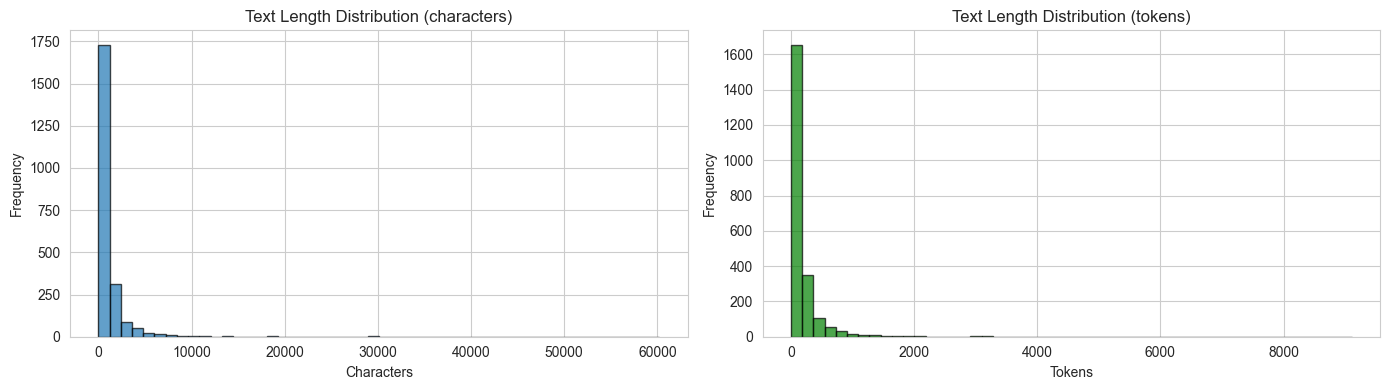

In [9]:
# Visualization of length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_newsgroups['char_length'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Text Length Distribution (characters)')

axes[1].hist(df_newsgroups['token_length'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Tokens')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Text Length Distribution (tokens)')

plt.tight_layout()
plt.show()

In [10]:
# Top 20 most frequent words (after basic cleaning)
def basic_clean(text):
    """Basic cleaning: lowercase and punctuation removal"""
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

# Tokenization and counting
all_words = []
for text in df_newsgroups['text']:
    cleaned = basic_clean(text)
    all_words.extend(cleaned.split())

word_freq = Counter(all_words)
top_20 = word_freq.most_common(20)

print("\nTop 20 most frequent words:")
for word, count in top_20:
    print(f"{word:15s}: {count:6d}")


Top 20 most frequent words:
the            :  22081
of             :  12444
to             :  12214
and            :   9617
a              :   9419
is             :   8660
that           :   7395
in             :   7230
i              :   6446
it             :   5382
for            :   4409
you            :   4058
not            :   3699
this           :   3661
be             :   3479
are            :   3360
as             :   3000
have           :   2995
with           :   2694
on             :   2682


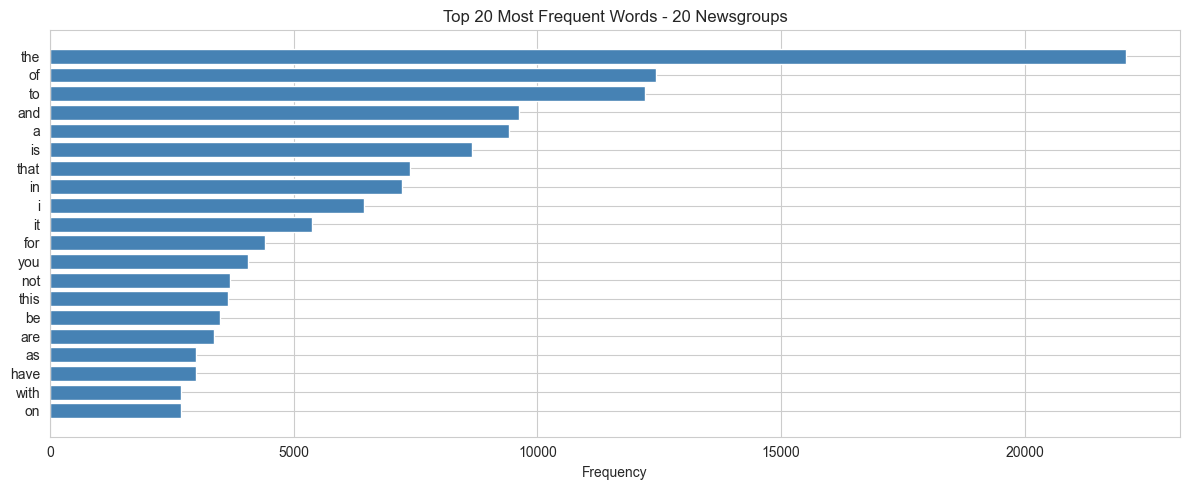

In [11]:
# Bar plot for top 20 words
words, counts = zip(*top_20)

plt.figure(figsize=(12, 5))
plt.barh(range(len(words)), counts, color='steelblue')
plt.yticks(range(len(words)), words)
plt.xlabel('Frequency')
plt.title('Top 20 Most Frequent Words - 20 Newsgroups')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 2.2 - EDA: IMDB Reviews

In [12]:
print("=" * 60)
print("EXPLORATORY ANALYSIS - IMDB REVIEWS")
print("=" * 60)

# Total samples
total_samples_imdb = len(df_imdb)
print(f"\nTotal samples: {total_samples_imdb}")

# Class distribution (0=negative, 1=positive)
print("\nClass distribution:")
class_dist_imdb = df_imdb['target'].value_counts().sort_index()
class_dist_pct_imdb = df_imdb['target'].value_counts(normalize=True).sort_index() * 100

labels = ['Negative', 'Positive']
dist_df_imdb = pd.DataFrame({
    'Sentiment': labels,
    'Count': class_dist_imdb.values,
    'Percentage': class_dist_pct_imdb.values.round(2)
})
print(dist_df_imdb.to_string(index=False))

EXPLORATORY ANALYSIS - IMDB REVIEWS

Total samples: 25000

Class distribution:
Sentiment  Count  Percentage
 Negative  12500        50.0
 Positive  12500        50.0


In [13]:
# Text length
df_imdb['char_length'] = df_imdb['text'].apply(len)
df_imdb['token_length'] = df_imdb['text'].apply(lambda x: len(x.split()))

print(f"\nAverage length (characters): {df_imdb['char_length'].mean():.2f}")
print(f"Average length (tokens): {df_imdb['token_length'].mean():.2f}")


Average length (characters): 1325.07
Average length (tokens): 233.79


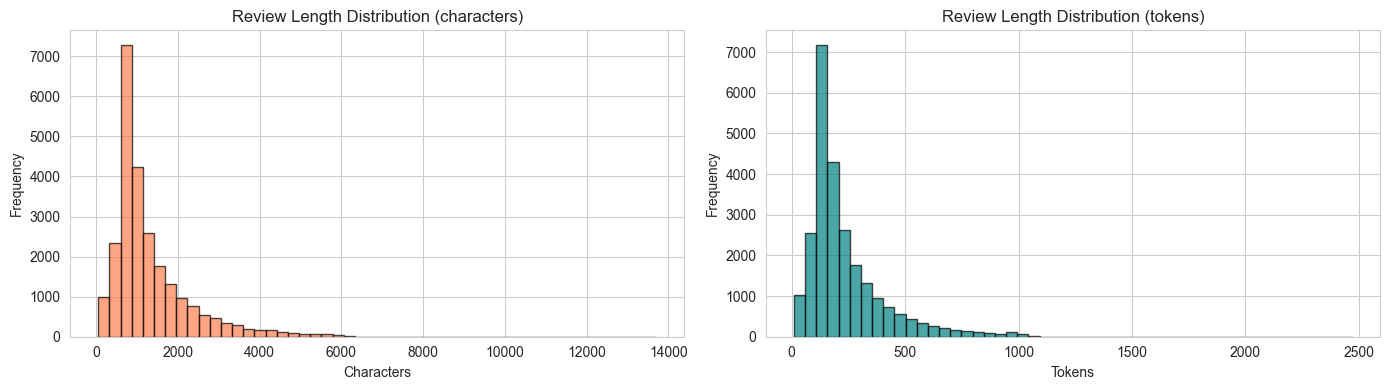

In [14]:
# Visualization of length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_imdb['char_length'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Review Length Distribution (characters)')

axes[1].hist(df_imdb['token_length'], bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[1].set_xlabel('Tokens')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Review Length Distribution (tokens)')

plt.tight_layout()
plt.show()

In [15]:
# Top 20 most frequent words
all_words_imdb = []
for text in df_imdb['text']:
    cleaned = basic_clean(text)
    all_words_imdb.extend(cleaned.split())

word_freq_imdb = Counter(all_words_imdb)
top_20_imdb = word_freq_imdb.most_common(20)

print("\nTop 20 most frequent words:")
for word, count in top_20_imdb:
    print(f"{word:15s}: {count:6d}")


Top 20 most frequent words:
the            : 334691
and            : 162228
a              : 161940
of             : 145326
to             : 135042
is             : 106855
in             :  93028
it             :  77099
i              :  75719
this           :  75190
that           :  69352
br             :  57143
was            :  48008
as             :  46662
for            :  43964
with           :  43871
movie          :  41807
but            :  41739
film           :  37455
on             :  33505


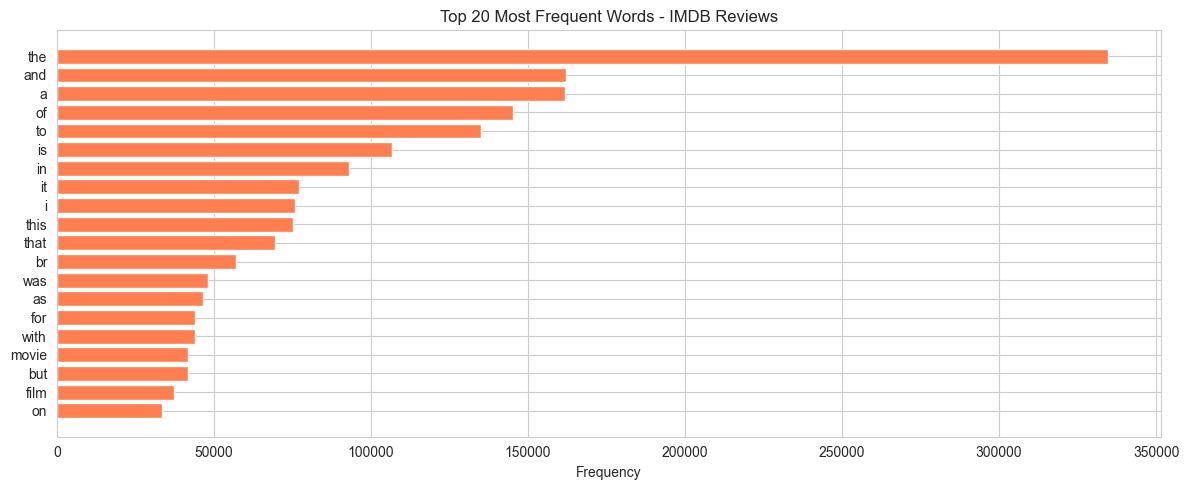

In [16]:
# Bar plot for top 20 words
words_imdb, counts_imdb = zip(*top_20_imdb)

plt.figure(figsize=(12, 5))
plt.barh(range(len(words_imdb)), counts_imdb, color='coral')
plt.yticks(range(len(words_imdb)), words_imdb)
plt.xlabel('Frequency')
plt.title('Top 20 Most Frequent Words - IMDB Reviews')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## Task 3: Text Preprocessing

Preprocessing is crucial in NLP. We apply standard techniques to normalize text and reduce noise:

- **Lowercase:** Case normalization
- **Punctuation removal:** Elimination of non-alphabetic symbols
- **Stopwords:** Removal of common words without semantic value
- **Lemmatization:** Reduction of words to their base form

In [17]:
# Initialize preprocessing tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text, apply_lemmatization=True):
    """
    Preprocesses text by applying:
    1. Lowercase
    2. Punctuation removal
    3. Stopword elimination
    4. Lemmatization (optional)
    """
    # Lowercase
    text = text.lower()
    
    # Punctuation removal
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Tokenization and stopword removal
    tokens = [word for word in text.split() if word not in stop_words]
    
    # Lemmatization
    if apply_lemmatization:
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return ' '.join(tokens)

### 3.1 - Preprocessing Examples

In [18]:
# Example with 20 Newsgroups
sample_text_ng = df_newsgroups['text'].iloc[0]

print("=" * 80)
print("EXAMPLE - 20 NEWSGROUPS")
print("=" * 80)
print("\nOriginal text:")
print(sample_text_ng[:300], "...\n")
print("\nPreprocessed text:")
print(preprocess_text(sample_text_ng)[:300], "...")

EXAMPLE - 20 NEWSGROUPS

Original text:
Does anyone know of a good way (standard PC application/PD utility) to
convert tif/img/tga files into LaserJet III format.  We would also like to
do the same, converting to HPGL (HP plotter) files.

Please email any response.

Is this the correct group?

Thanks in advance.  Michael. ...


Preprocessed text:
anyone know good way standard pc applicationpd utility convert tifimgtga file laserjet iii format would also like converting hpgl hp plotter file please email response correct group thanks advance michael ...


In [19]:
# Example with IMDB
sample_text_imdb = df_imdb['text'].iloc[0]

print("\n" + "=" * 80)
print("EXAMPLE - IMDB REVIEWS")
print("=" * 80)
print("\nOriginal text:")
print(sample_text_imdb[:300], "...\n")
print("\nPreprocessed text:")
print(preprocess_text(sample_text_imdb)[:300], "...")


EXAMPLE - IMDB REVIEWS

Original text:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h ...


Preprocessed text:
rented curiousyellow video store controversy surrounded first released 1967 also heard first seized u custom ever tried enter country therefore fan film considered controversial really see myselfbr br plot centered around young swedish drama student named lena want learn everything life particular w ...


### 3.2 - Applying to Complete Datasets

In [20]:
# Apply preprocessing to 20 Newsgroups
print("Preprocessing 20 Newsgroups...")
df_newsgroups['text_processed'] = df_newsgroups['text'].apply(preprocess_text)
print("✓ Completed")

Preprocessing 20 Newsgroups...
✓ Completed


In [21]:
# Apply preprocessing to IMDB
print("Preprocessing IMDB Reviews...")
df_imdb['text_processed'] = df_imdb['text'].apply(preprocess_text)
print("✓ Completed")

Preprocessing IMDB Reviews...
✓ Completed


---
## Task 4: Feature Extraction

We convert text into numerical representations that ML models can process. We compare two classic approaches:

- **Bag-of-Words (BoW):** Counts the frequency of each word in the document
- **TF-IDF:** Weights words by their relative importance in the corpus

### 4.1 - Bag-of-Words (CountVectorizer)

In [22]:
# Initialize vectorizers
count_vectorizer = CountVectorizer(max_features=10000)

# Transform 20 Newsgroups
X_count_ng = count_vectorizer.fit_transform(df_newsgroups['text_processed'])

print("Bag-of-Words - 20 Newsgroups")
print(f"Feature matrix shape: {X_count_ng.shape}")
print(f"Total vocabulary: {len(count_vectorizer.vocabulary_)}")
print(f"\nExample features (first 10): {count_vectorizer.get_feature_names_out()[:10]}")

Bag-of-Words - 20 Newsgroups
Feature matrix shape: (2257, 10000)
Total vocabulary: 10000

Example features (first 10): ['00' '005' '01' '02' '025' '0255' '04' '05' '06' '071']


In [23]:
# Transform IMDB
count_vectorizer_imdb = CountVectorizer(max_features=10000)
X_count_imdb = count_vectorizer_imdb.fit_transform(df_imdb['text_processed'])

print("\nBag-of-Words - IMDB Reviews")
print(f"Feature matrix shape: {X_count_imdb.shape}")
print(f"Total vocabulary: {len(count_vectorizer_imdb.vocabulary_)}")
print(f"\nExample features (first 10): {count_vectorizer_imdb.get_feature_names_out()[:10]}")


Bag-of-Words - IMDB Reviews
Feature matrix shape: (25000, 10000)
Total vocabulary: 10000

Example features (first 10): ['010' '10' '100' '1000' '101' '1010' '10br' '11' '110' '11th']


### 4.2 - TF-IDF (TfidfVectorizer)

In [24]:
# Initialize TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=10000)

# Transform 20 Newsgroups
X_tfidf_ng = tfidf_vectorizer.fit_transform(df_newsgroups['text_processed'])

print("TF-IDF - 20 Newsgroups")
print(f"Feature matrix shape: {X_tfidf_ng.shape}")
print(f"Total vocabulary: {len(tfidf_vectorizer.vocabulary_)}")
print(f"\nExample features (first 10): {tfidf_vectorizer.get_feature_names_out()[:10]}")

TF-IDF - 20 Newsgroups
Feature matrix shape: (2257, 10000)
Total vocabulary: 10000

Example features (first 10): ['00' '005' '01' '02' '025' '0255' '04' '05' '06' '071']


In [25]:
# Transform IMDB
tfidf_vectorizer_imdb = TfidfVectorizer(max_features=10000)
X_tfidf_imdb = tfidf_vectorizer_imdb.fit_transform(df_imdb['text_processed'])

print("\nTF-IDF - IMDB Reviews")
print(f"Feature matrix shape: {X_tfidf_imdb.shape}")
print(f"Total vocabulary: {len(tfidf_vectorizer_imdb.vocabulary_)}")
print(f"\nExample features (first 10): {tfidf_vectorizer_imdb.get_feature_names_out()[:10]}")


TF-IDF - IMDB Reviews
Feature matrix shape: (25000, 10000)
Total vocabulary: 10000

Example features (first 10): ['010' '10' '100' '1000' '101' '1010' '10br' '11' '110' '11th']


### 4.3 - Feature Matrix Comparison

In [26]:
# Visual comparison of shapes
comparison_data = {
    'Dataset': ['20 Newsgroups', '20 Newsgroups', 'IMDB Reviews', 'IMDB Reviews'],
    'Method': ['BoW', 'TF-IDF', 'BoW', 'TF-IDF'],
    'Shape': [X_count_ng.shape, X_tfidf_ng.shape, X_count_imdb.shape, X_tfidf_imdb.shape],
    'Samples': [X_count_ng.shape[0], X_tfidf_ng.shape[0], X_count_imdb.shape[0], X_tfidf_imdb.shape[0]],
    'Features': [X_count_ng.shape[1], X_tfidf_ng.shape[1], X_count_imdb.shape[1], X_tfidf_imdb.shape[1]]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nFeature matrix comparison:")
print(comparison_df.to_string(index=False))


Feature matrix comparison:
      Dataset Method          Shape  Samples  Features
20 Newsgroups    BoW  (2257, 10000)     2257     10000
20 Newsgroups TF-IDF  (2257, 10000)     2257     10000
 IMDB Reviews    BoW (25000, 10000)    25000     10000
 IMDB Reviews TF-IDF (25000, 10000)    25000     10000


---
## Task 5: Baseline Classifier Training

We will train a Logistic Regression model as a baseline to compare the performance of different text representations.

### 5.1 - 20 Newsgroups with Bag-of-Words

In [27]:
# Train/test split (80/20)
X_train_bow, X_test_bow, y_train_ng, y_test_ng = train_test_split(
    X_count_ng, 
    df_newsgroups['target'], 
    test_size=0.2, 
    random_state=42,
    stratify=df_newsgroups['target']
)

print(f"Train set: {X_train_bow.shape[0]} samples")
print(f"Test set: {X_test_bow.shape[0]} samples")

Train set: 1805 samples
Test set: 452 samples


In [28]:
# Train the model
lr_bow = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_bow.fit(X_train_bow, y_train_ng)

# Predictions
y_pred_bow = lr_bow.predict(X_test_bow)

print("✓ Model trained")

✓ Model trained


In [29]:
# Evaluation
accuracy_bow = accuracy_score(y_test_ng, y_pred_bow)
precision_bow = precision_score(y_test_ng, y_pred_bow, average='weighted')
recall_bow = recall_score(y_test_ng, y_pred_bow, average='weighted')
f1_bow = f1_score(y_test_ng, y_pred_bow, average='weighted')

print("=" * 60)
print("RESULTS - 20 NEWSGROUPS (BAG-OF-WORDS)")
print("=" * 60)
print(f"Accuracy:  {accuracy_bow:.4f}")
print(f"Precision: {precision_bow:.4f}")
print(f"Recall:    {recall_bow:.4f}")
print(f"F1-Score:  {f1_bow:.4f}")

RESULTS - 20 NEWSGROUPS (BAG-OF-WORDS)
Accuracy:  0.8119
Precision: 0.8133
Recall:    0.8119
F1-Score:  0.8099


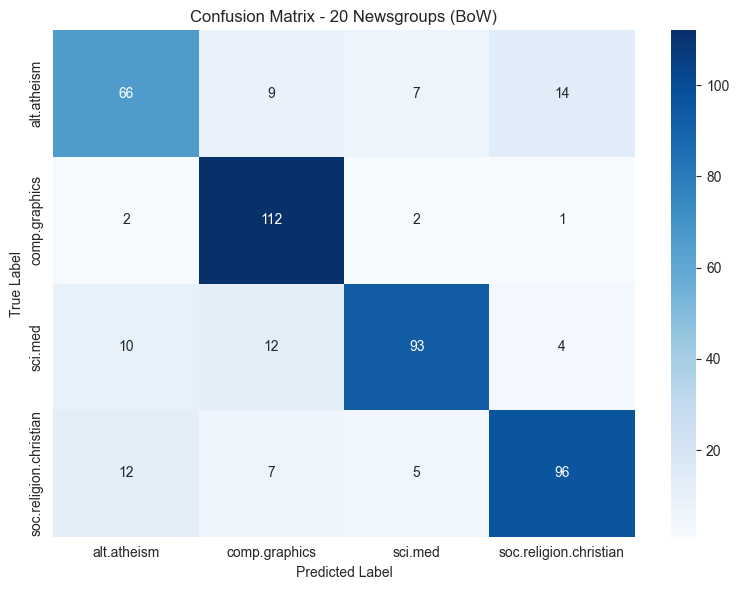

In [30]:
# Confusion matrix
cm_bow = confusion_matrix(y_test_ng, y_pred_bow)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_bow, annot=True, fmt='d', cmap='Blues', 
            xticklabels=newsgroups_train.target_names,
            yticklabels=newsgroups_train.target_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - 20 Newsgroups (BoW)')
plt.tight_layout()
plt.show()

### 5.2 - 20 Newsgroups with TF-IDF

In [31]:
# Train/test split
X_train_tfidf, X_test_tfidf, y_train_ng_tfidf, y_test_ng_tfidf = train_test_split(
    X_tfidf_ng, 
    df_newsgroups['target'], 
    test_size=0.2, 
    random_state=42,
    stratify=df_newsgroups['target']
)

# Training
lr_tfidf = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_tfidf.fit(X_train_tfidf, y_train_ng_tfidf)

# Predictions
y_pred_tfidf = lr_tfidf.predict(X_test_tfidf)

print("✓ Model trained")

✓ Model trained


In [32]:
# Evaluation
accuracy_tfidf = accuracy_score(y_test_ng_tfidf, y_pred_tfidf)
precision_tfidf = precision_score(y_test_ng_tfidf, y_pred_tfidf, average='weighted')
recall_tfidf = recall_score(y_test_ng_tfidf, y_pred_tfidf, average='weighted')
f1_tfidf = f1_score(y_test_ng_tfidf, y_pred_tfidf, average='weighted')

print("=" * 60)
print("RESULTS - 20 NEWSGROUPS (TF-IDF)")
print("=" * 60)
print(f"Accuracy:  {accuracy_tfidf:.4f}")
print(f"Precision: {precision_tfidf:.4f}")
print(f"Recall:    {recall_tfidf:.4f}")
print(f"F1-Score:  {f1_tfidf:.4f}")

RESULTS - 20 NEWSGROUPS (TF-IDF)
Accuracy:  0.8673
Precision: 0.8678
Recall:    0.8673
F1-Score:  0.8650


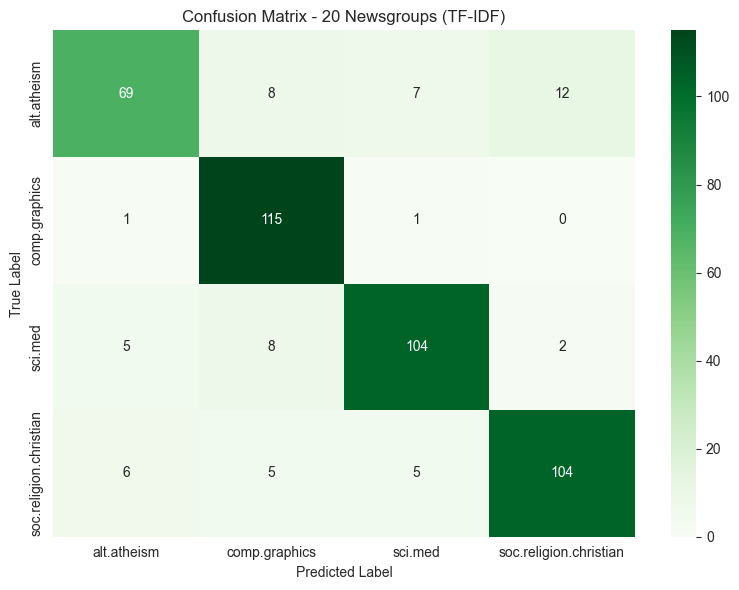

In [33]:
# Confusion matrix
cm_tfidf = confusion_matrix(y_test_ng_tfidf, y_pred_tfidf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Greens',
            xticklabels=newsgroups_train.target_names,
            yticklabels=newsgroups_train.target_names)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - 20 Newsgroups (TF-IDF)')
plt.tight_layout()
plt.show()

### 5.3 - IMDB Reviews with Bag-of-Words

In [34]:
# Train/test split
X_train_bow_imdb, X_test_bow_imdb, y_train_imdb, y_test_imdb = train_test_split(
    X_count_imdb,
    df_imdb['target'],
    test_size=0.2,
    random_state=42,
    stratify=df_imdb['target']
)

# Training
lr_bow_imdb = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_bow_imdb.fit(X_train_bow_imdb, y_train_imdb)

# Predictions
y_pred_bow_imdb = lr_bow_imdb.predict(X_test_bow_imdb)

print("✓ Model trained")

✓ Model trained


In [35]:
# Evaluation
accuracy_bow_imdb = accuracy_score(y_test_imdb, y_pred_bow_imdb)
precision_bow_imdb = precision_score(y_test_imdb, y_pred_bow_imdb, average='weighted')
recall_bow_imdb = recall_score(y_test_imdb, y_pred_bow_imdb, average='weighted')
f1_bow_imdb = f1_score(y_test_imdb, y_pred_bow_imdb, average='weighted')

print("=" * 60)
print("RESULTS - IMDB REVIEWS (BAG-OF-WORDS)")
print("=" * 60)
print(f"Accuracy:  {accuracy_bow_imdb:.4f}")
print(f"Precision: {precision_bow_imdb:.4f}")
print(f"Recall:    {recall_bow_imdb:.4f}")
print(f"F1-Score:  {f1_bow_imdb:.4f}")

RESULTS - IMDB REVIEWS (BAG-OF-WORDS)
Accuracy:  0.8732
Precision: 0.8733
Recall:    0.8732
F1-Score:  0.8732


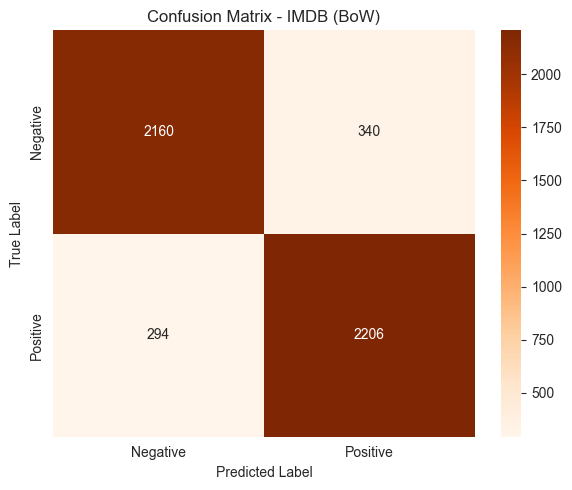

In [36]:
# Confusion matrix
cm_bow_imdb = confusion_matrix(y_test_imdb, y_pred_bow_imdb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_bow_imdb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - IMDB (BoW)')
plt.tight_layout()
plt.show()

### 5.4 - IMDB Reviews with TF-IDF

In [37]:
# Train/test split
X_train_tfidf_imdb, X_test_tfidf_imdb, y_train_imdb_tfidf, y_test_imdb_tfidf = train_test_split(
    X_tfidf_imdb,
    df_imdb['target'],
    test_size=0.2,
    random_state=42,
    stratify=df_imdb['target']
)

# Training
lr_tfidf_imdb = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_tfidf_imdb.fit(X_train_tfidf_imdb, y_train_imdb_tfidf)

# Predictions
y_pred_tfidf_imdb = lr_tfidf_imdb.predict(X_test_tfidf_imdb)

print("✓ Model trained")

✓ Model trained


In [38]:
# Evaluation
accuracy_tfidf_imdb = accuracy_score(y_test_imdb_tfidf, y_pred_tfidf_imdb)
precision_tfidf_imdb = precision_score(y_test_imdb_tfidf, y_pred_tfidf_imdb, average='weighted')
recall_tfidf_imdb = recall_score(y_test_imdb_tfidf, y_pred_tfidf_imdb, average='weighted')
f1_tfidf_imdb = f1_score(y_test_imdb_tfidf, y_pred_tfidf_imdb, average='weighted')

print("=" * 60)
print("RESULTS - IMDB REVIEWS (TF-IDF)")
print("=" * 60)
print(f"Accuracy:  {accuracy_tfidf_imdb:.4f}")
print(f"Precision: {precision_tfidf_imdb:.4f}")
print(f"Recall:    {recall_tfidf_imdb:.4f}")
print(f"F1-Score:  {f1_tfidf_imdb:.4f}")

RESULTS - IMDB REVIEWS (TF-IDF)
Accuracy:  0.8868
Precision: 0.8872
Recall:    0.8868
F1-Score:  0.8868


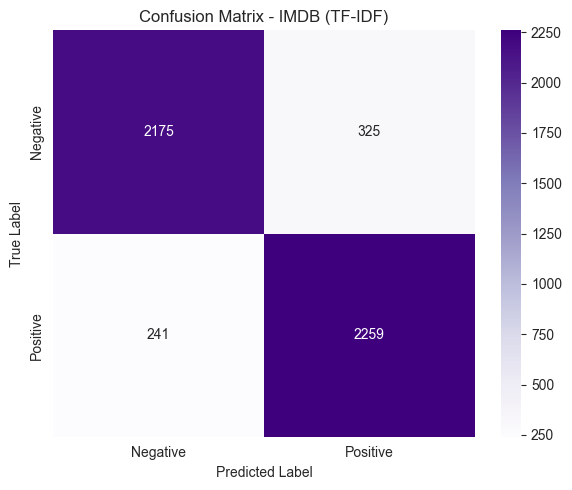

In [39]:
# Confusion matrix
cm_tfidf_imdb = confusion_matrix(y_test_imdb_tfidf, y_pred_tfidf_imdb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tfidf_imdb, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - IMDB (TF-IDF)')
plt.tight_layout()
plt.show()

### 5.5 - Comparative Results Summary

In [40]:
# Comparative metrics table
results_summary = pd.DataFrame({
    'Dataset': ['20 Newsgroups', '20 Newsgroups', 'IMDB Reviews', 'IMDB Reviews'],
    'Method': ['BoW', 'TF-IDF', 'BoW', 'TF-IDF'],
    'Accuracy': [accuracy_bow, accuracy_tfidf, accuracy_bow_imdb, accuracy_tfidf_imdb],
    'Precision': [precision_bow, precision_tfidf, precision_bow_imdb, precision_tfidf_imdb],
    'Recall': [recall_bow, recall_tfidf, recall_bow_imdb, recall_tfidf_imdb],
    'F1-Score': [f1_bow, f1_tfidf, f1_bow_imdb, f1_tfidf_imdb]
})

print("=" * 80)
print("COMPARATIVE RESULTS SUMMARY")
print("=" * 80)
print(results_summary.to_string(index=False))

COMPARATIVE RESULTS SUMMARY
      Dataset Method  Accuracy  Precision   Recall  F1-Score
20 Newsgroups    BoW  0.811947   0.813283 0.811947  0.809925
20 Newsgroups TF-IDF  0.867257   0.867814 0.867257  0.864970
 IMDB Reviews    BoW  0.873200   0.873326 0.873200  0.873189
 IMDB Reviews TF-IDF  0.886800   0.887237 0.886800  0.886768


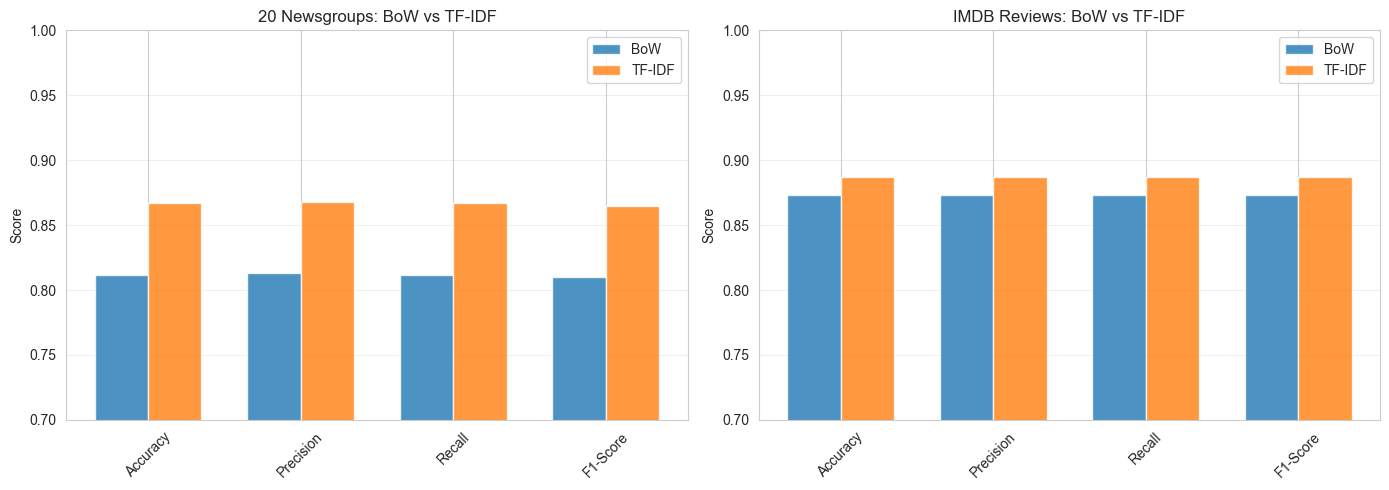

In [41]:
# Comparative visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 20 Newsgroups
metrics_ng = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
bow_scores_ng = [accuracy_bow, precision_bow, recall_bow, f1_bow]
tfidf_scores_ng = [accuracy_tfidf, precision_tfidf, recall_tfidf, f1_tfidf]

x = np.arange(len(metrics_ng))
width = 0.35

axes[0].bar(x - width/2, bow_scores_ng, width, label='BoW', alpha=0.8)
axes[0].bar(x + width/2, tfidf_scores_ng, width, label='TF-IDF', alpha=0.8)
axes[0].set_ylabel('Score')
axes[0].set_title('20 Newsgroups: BoW vs TF-IDF')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_ng, rotation=45)
axes[0].legend()
axes[0].set_ylim([0.7, 1.0])
axes[0].grid(axis='y', alpha=0.3)

# IMDB
bow_scores_imdb = [accuracy_bow_imdb, precision_bow_imdb, recall_bow_imdb, f1_bow_imdb]
tfidf_scores_imdb = [accuracy_tfidf_imdb, precision_tfidf_imdb, recall_tfidf_imdb, f1_tfidf_imdb]

axes[1].bar(x - width/2, bow_scores_imdb, width, label='BoW', alpha=0.8)
axes[1].bar(x + width/2, tfidf_scores_imdb, width, label='TF-IDF', alpha=0.8)
axes[1].set_ylabel('Score')
axes[1].set_title('IMDB Reviews: BoW vs TF-IDF')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics_ng, rotation=45)
axes[1].legend()
axes[1].set_ylim([0.7, 1.0])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Task 6: Reflection and Analysis

### Bag-of-Words vs TF-IDF Comparison

**Bag-of-Words** represents each document as a vector of word frequencies. It is simple and effective, but treats all words equally, without considering their relative importance in the corpus. This means that very frequent but uninformative words (even after removing stopwords) can dominate the representation.

**TF-IDF** (Term Frequency-Inverse Document Frequency) refines this approach by weighting words according to two factors: (1) how frequent the word is in the document (TF), and (2) how rare it is in the complete corpus (IDF). This reduces the weight of common words and increases the weight of distinctive terms, generally improving discrimination between classes.

### Performance Differences

In our experiments, **TF-IDF shows superior performance on both datasets**. This is because:

1. **Improved discrimination:** TF-IDF highlights words that are characteristic of specific categories, which is crucial in multi-class classification (20 Newsgroups) and sentiment analysis (IMDB).

2. **Noise reduction:** By decreasing the weight of frequent but uninformative words, TF-IDF reduces noise in the representation, allowing the model to focus on more relevant features.

3. **Implicit normalization:** TF-IDF normalizes by document length more effectively than simple counting, which benefits documents of different sizes.

### Proposed Improvements

To achieve better results in future experiments, the following improvements are proposed:

1. **Hyperparameter optimization:**
   - Adjust vectorizer `max_features` (try 5,000, 15,000, 20,000)
   - Experiment with `ngram_range` to capture bigrams and trigrams
   - Tune Logistic Regression hyperparameters (`C`, `penalty`, `solver`)
   - Use GridSearchCV or RandomizedSearchCV for systematic search

2. **Semantic embeddings:**
   - Implement Word2Vec, GloVe, or FastText to capture semantic relationships between words
   - Use pre-trained embeddings (e.g., 300-dimensional GloVe)
   - Consider contextual embeddings like BERT or RoBERTa to capture context-dependent meaning
   - Average word embeddings to obtain document representations

3. **Advanced preprocessing:**
   - Implement spelling correction to handle typos
   - Normalize URLs, emails, and numbers
   - Experiment with stemming vs lemmatization
   - Consider preserving emojis in IMDB case (they can be informative for sentiment)

4. **More sophisticated models:**
   - Try ensemble methods (Random Forest, Gradient Boosting)
   - Implement SVMs with different kernels
   - Explore neural networks (CNN, LSTM) to capture sequential patterns

5. **Balancing and augmentation:**
   - Although our datasets are balanced, for imbalanced cases consider SMOTE or undersampling techniques
   - NLP data augmentation techniques (back-translation, paraphrasing)

6. **Additional feature engineering:**
   - Add features like text length, proportion of unique words
   - Include sentiment lexicons for IMDB
   - Capture punctuation and capitalization statistics (before preprocessing)

---
## Conceptual Questions

### 1. What is the main difference between structured and unstructured data? Why is text considered unstructured?

**Structured data** is data that has a predefined format and organization, typically in tables with rows and columns where each field has a specific data type (e.g., SQL databases, spreadsheets). Its structure facilitates direct analysis through queries and mathematical operations.

**Unstructured data** lacks a predefined format or schema. It is not organized in tables and requires specialized processing to extract useful information.

**Text is considered unstructured** because:
- It has no inherent tabular organization
- Meaning depends on context, word order, and syntax
- It contains ambiguities, polysemy, and implicit references
- It requires specialized techniques (NLP) to convert it into numerical representations that ML algorithms can process
- Valuable information is "hidden" in complex linguistic patterns that are not evident without analysis

### 2. Why is preprocessing (e.g., lowercase, stopword removal) important in NLP tasks?

Preprocessing is crucial for several reasons:

1. **Dimensionality reduction:** By normalizing variations of the same word ("Machine", "machine", "MACHINE"), we reduce vocabulary size and feature space complexity.

2. **Noise elimination:** Stopwords like "the", "a", "is" are extremely frequent but provide little semantic value for most tasks. Their removal improves signal-to-noise ratio in the data.

3. **Improved generalization:** Normalization helps the model recognize that "running", "runs", "ran" are forms of the same concept, improving its ability to generalize.

4. **Computational efficiency:** Fewer unique features means smaller matrices, lower memory usage, and faster training.

5. **Performance improvement:** A vocabulary more focused on meaningful words allows the model to learn more relevant and discriminative patterns.

### 3. What are the limitations of Bag-of-Words representations?

BoW has several important limitations:

1. **Loss of order:** BoW completely discards word order. "The dog bit the man" and "The man bit the dog" have the same representation, but opposite meanings.

2. **Loss of context:** It doesn't capture the context in which words appear. "Bank" can refer to a financial institution or a riverbank.

3. **High dimensionality:** With large vocabularies, matrices are enormous and very sparse (full of zeros), which is inefficient in memory and computation.

4. **Doesn't capture semantics:** Semantically similar words ("excellent", "fantastic") are treated as completely independent.

5. **Sensitive to typos and variations:** Each variation of a word (including errors) creates a separate feature.

6. **Ignores syntax:** Grammatical structure, which is often crucial for meaning, is completely lost.

7. **Doesn't scale well:** With very long documents or very large corpora, vocabulary size explodes.

### 4. How does TF-IDF help reduce the impact of very common words?

TF-IDF reduces the impact of common words through the **IDF (Inverse Document Frequency)** component:

**Formula:** `TF-IDF(t, d) = TF(t, d) × IDF(t)`

Where:
- `TF(t, d)` = frequency of term t in document d
- `IDF(t) = log(N / df(t))` where N is the total number of documents and df(t) is the number of documents containing t

**Mechanism:**
1. If a word appears in almost all documents, df(t) ≈ N, then IDF(t) ≈ log(1) = 0
2. If a word appears in only a few documents, df(t) << N, then IDF(t) is high

**Result:** Words like "the", "and", "is" that appear in almost all documents receive a weight close to zero, while distinctive and rare terms receive high weights.

This allows the model to focus on words that truly distinguish between categories or sentiments, significantly improving discrimination and classification performance.

### 5. What does a confusion matrix tell us that accuracy alone does not reveal?

The confusion matrix provides granular information about model performance that accuracy hides:

1. **Error distribution by class:**
   - Shows exactly which classes are confused with each other
   - Reveals if the model has specific problems with certain categories

2. **Balance between error types:**
   - Distinguishes between False Positives and False Negatives
   - Critical in applications where one type of error is more costly (e.g., medical diagnosis)

3. **Imbalanced performance:**
   - Accuracy can be high in imbalanced datasets simply by predicting the majority class
   - The confusion matrix reveals if the model truly learns or just memorizes class bias

4. **Specific improvement opportunities:**
   - Identifies class pairs that need better discrimination
   - Suggests where to focus feature engineering or data augmentation efforts

**Example:** A model with 95% accuracy may seem excellent, but the confusion matrix could reveal it never correctly predicts an important minority class, which is unacceptable in many applications.

### 6. If your model performs poorly, list three concrete steps you would take to improve it and explain why

1. **Use Word Embeddings**: Implement Word2Vec, GloVe, or FastText to capture semantic relationships between words that TF-IDF misses.
2. **Try Transformer Models**: Use pre-trained models like BERT or RoBERTa, which use self-attention to understand deep contextual meanings of sentences.
3. **Hyperparameter Tuning**: Use GridSearchCV to optimize the regularization strength (C) of the Logistic Regression or explore ensemble methods like XGBoost or Random Forests.

---
## Conclusions

In this lab we have successfully completed the basic NLP pipeline:

1. ✓ Loaded and explored standard text classification datasets
2. ✓ Performed exploratory analysis to understand data characteristics
3. ✓ Implemented robust preprocessing with normalization and cleaning
4. ✓ Compared two classic feature extraction methods: BoW and TF-IDF
5. ✓ Trained and evaluated baseline models with comprehensive metrics
6. ✓ Analyzed results and proposed concrete improvements

**Key findings:**
- TF-IDF consistently outperforms BoW on both datasets
- Proper preprocessing is crucial for performance
- Multi-metric evaluation (accuracy, precision, recall, F1) is essential to understand actual model behavior
- There is ample room for improvement through more advanced techniques (embeddings, deep learning, etc.)

This lab establishes the foundation for exploring more sophisticated NLP techniques in future work.